# Lab 10: Regression for cost estimation

Uses generated numerical cost data (seed 42), not real property prices. Cost is an arbitrary-unit illustrative target. A depth-limited regression tree estimates cost and is evaluated on a held-out test set.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


MAE: 17474.44380831291
RMSE: 23774.718434761664
R2: 0.9017047039223763
New cost estimate: 249830.59651089046


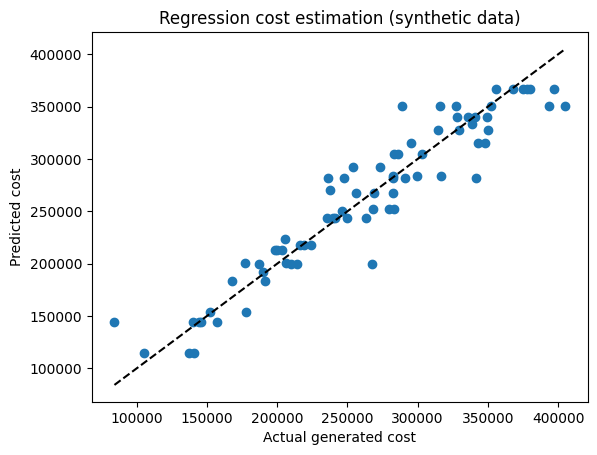

In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
rng=np.random.default_rng(42)
area=rng.uniform(500,2500,300);rooms=rng.integers(1,6,300);age=rng.uniform(0,40,300)
cost=50000+120*area+15000*rooms-800*age+rng.normal(0,15000,300)
df=pd.DataFrame({'Area_sqft':area,'Rooms':rooms,'Age_years':age,'Cost':cost});df.to_csv('generated_cost_data.csv',index=False)
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,:3],df['Cost'],test_size=.25,random_state=42)
model=DecisionTreeRegressor(max_depth=5,random_state=42);model.fit(X_train,y_train);pred=model.predict(X_test)
print('MAE:',mean_absolute_error(y_test,pred));print('RMSE:',np.sqrt(mean_squared_error(y_test,pred)));print('R2:',r2_score(y_test,pred))
print('New cost estimate:',model.predict(pd.DataFrame([[1500,3,10]],columns=X_train.columns))[0])
plt.figure();plt.scatter(y_test,pred);low=min(y_test.min(),pred.min());high=max(y_test.max(),pred.max());plt.plot([low,high],[low,high],'k--');plt.xlabel('Actual generated cost');plt.ylabel('Predicted cost');plt.title('Regression cost estimation (synthetic data)');plt.show()
